# 🚀 Mission : Pilotez l'atterrisseur lunaire Eagle-1

## 🎯 Objectif

Entraînez un agent **PPO** sur LunarLander-v3 pour atteindre une **récompense moyenne > 200**.

**Contexte :** Vous êtes ingénieur ML chez AstroDynamics, chargé de développer le pilote automatique pour le module d'atterrissage "Eagle-1".

---

## 📚 Prérequis

Cette mission fait suite aux exercices 1-3 :
- Concepts de Q-Learning et DQN
- Stable-Baselines3 pour l'entraînement
- Equilibre exploration/exploitation

## 🕹️ Mission 1 : Baseline & Exploration

Avant d'entraîner, explorons l'environnement **LunarLander-v3**.

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Créer l'environnement
env = gym.make("LunarLander-v3")
print(f"Action space: {env.action_space}")
print(f"Observation space: {env.observation_space}")
print(f"Observation shape: {env.observation_space.shape}")
print(f"Action space (discret): {env.action_space.n} options")
print("\n💡 Actions:")
print("  0: Ne rien faire (pas de thrust)")
print("  1: Allumer le moteur principal ( thrust)")
print("  2: Allumer le moteur gauche")
print("  3: Allumer le moteur droit")

Action space: Discrete(4)
Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Observation shape: (8,)
Action space (discret): 4 options

💡 Actions:
  0: Ne rien faire (pas de thrust)
  1: Allumer le moteur principal ( thrust)
  2: Allumer le moteur gauche
  3: Allumer le moteur droit


### Comprendre les observations

L'observation contient 8 valeurs :
- Position x, y (lander)
- Vitesse x, y
- Angle, vitesse angulaire
- Contact jambes gauche/droite

In [3]:
# Jouer quelques épisodes aléatoires pour comprendre l'environnement
n_episodes = 3

for episode in range(n_episodes):
    state, info = env.reset()
    total_reward = 0
    terminated = truncated = False
    
    print(f"\n=== Épisode {episode + 1} ===")
    print(f"État initial: {state}")
    
    steps = 0
    while not (terminated or truncated) and steps < 200:
        action = env.action_space.sample()
        state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1
    
    print(f"Steps: {steps}, Reward total: {total_reward:.1f}")

env.close()


=== Épisode 1 ===
État initial: [-1.3551713e-04  1.4168559e+00 -1.3740403e-02  2.6381227e-01
  1.6379863e-04  3.1124011e-03  0.0000000e+00  0.0000000e+00]
Steps: 98, Reward total: -352.7

=== Épisode 2 ===
État initial: [ 2.7027130e-04  1.4177330e+00  2.7363081e-02  3.0279651e-01
 -3.0641616e-04 -6.1981436e-03  0.0000000e+00  0.0000000e+00]
Steps: 105, Reward total: -341.3

=== Épisode 3 ===
État initial: [ 0.0053421   1.405348    0.5410882  -0.24766088 -0.00618343 -0.12256454
  0.          0.        ]
Steps: 67, Reward total: -141.1


**💡 Observation :** L'agent aléatoire obtient des rewards négatifs (entre -200 et -100) car il tombe et crash !

---

## 🏋️ Mission 2 : Entraînement & Optimisation

Nous allons utiliser **PPO** (Proximal Policy Optimization), excellent pour LunarLander.

**Pourquoi PPO ?**
- Plus stable que DQN pour les tâches continues
- Meilleure convergence
- Fonctionne bien avec Stable-Baselines3

In [32]:
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback
import os

In [33]:
# Créer l'environnement
env = gym.make("LunarLander-v3")

# Créer le modèle PPO
model = PPO(
    policy='MlpPolicy',
    env=env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    verbose=1
)

print("Modèle PPO créé !")
print("\n💡 Les paramètres clés :")
print("  - n_steps: combien de steps avant mise à jour (2048)")
print("  - n_epochs: combien de passes sur les données (10)")
print("  - clip_range: limite le changement de politique (0.2)")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Modèle PPO créé !

💡 Les paramètres clés :
  - n_steps: combien de steps avant mise à jour (2048)
  - n_epochs: combien de passes sur les données (10)
  - clip_range: limite le changement de politique (0.2)


In [34]:
print("Lancement de l'entraînement PPO...")
print("-" * 50)

# Entraîner (100000 steps ≈ 500 épisodes)
model.learn(total_timesteps=100000)

print("\n✅ Entraînement terminé !")

Lancement de l'entraînement PPO...
--------------------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 93.1     |
|    ep_rew_mean     | -163     |
| time/              |          |
|    fps             | 995      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 96.4        |
|    ep_rew_mean          | -166        |
| time/                   |             |
|    fps                  | 190         |
|    iterations           | 2           |
|    time_elapsed         | 21          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.014994839 |
|    clip_fraction        | 0.0909      |
|    clip_range           | 0.2         |
|    entropy_loss         | 

---

## 🔧 Optimisation : Hyperparamètres et Early Stopping

### Pourquoi ajuster les hyperparamètres ?

L'agent n'a pas atteint 200 points.

**Conseils pour atteindre 200 :**
- LunarLander est difficile : il faut souvent 200k-500k steps
- Le reward varie beaucoup : un atterrissage réussi = +200, un crash = -100
- Parfois il faut réinitialiser (nouveau seed) si l'agent stagne

**Règle d'or :** Modifier **un seul paramètre à la fois** pour savoir ce qui fonctionne.

### Paramètres clés pour PPO

| Paramètre | Effet | Valeur par défaut | Tester |
|-----------|-------|-------------------|--------|
| `learning_rate` | Vitesse d'apprentissage | 3e-4 | 1e-4 à 5e-4 |
| `n_steps` | Échantillons avant mise à jour | 2048 | 1024-4096 |
| `n_epochs` | Passes sur les données | 10 | 5-20 |
| `ent_coef` | Encouragement exploration | 0.01 | 0.0-0.1 |

### Early Stopping : Arrêter quand l'objectif est atteint

Au lieu de fixer un nombre arbitraire de steps, on utilise un callback qui arrête automatiquement quand l'agent atteint l'objectif.

In [35]:
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
import numpy as np

class EarlyStoppingCallback(BaseCallback):
    """Callback personnalisé pour arrêter quand l'objectif est atteint"""
    
    def __init__(self, threshold: float, patience: int, eval_freq: int, verbose: int = 1):
        super().__init__(verbose)
        self.threshold = threshold
        self.patience = patience
        self.eval_freq = eval_freq
        self.best_mean_reward = -float('inf')
        self.wait = 0
        
    def _on_step(self) -> bool:
        if self.n_calls % self.eval_freq == 0:
            mean_reward, _ = evaluate_policy(self.model, self.model.get_env(), n_eval_episodes=10)
            if self.verbose:
                print(f"Step {self.n_calls}: reward moyen = {mean_reward:.1f}")
            
            if mean_reward > self.best_mean_reward:
                self.best_mean_reward = mean_reward
                self.wait = 0
            else:
                self.wait += 1
                
            if mean_reward > self.threshold:
                if self.verbose:
                    print(f"🎉 Objectif atteint ! Reward = {mean_reward:.1f}")
                return False  # Arrête l'entraînement
            
            if self.wait >= self.patience:
                if self.verbose:
                    print(f"⏹️ Early stopping: pas d'amélioration après {self.patience} évaluations")
                return False
        
        return True

# Nouveau modèle avec hyperparamètres ajustés
env_tuned = gym.make("LunarLander-v3")

model_tuned = PPO(
    policy='MlpPolicy',
    env=env_tuned,
    learning_rate=3e-4,       # Standard pour LunarLander
    n_steps=2048,             # Buffer standard
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.0,             # Moins d'exploration (PPO stable)
    verbose=1
)

print("=== Expérimentation : Hyperparamètres ajustés ===")
print("Modifications : learning_rate=1e-4, n_steps=1024, ent_coef=0.02")


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
=== Expérimentation : Hyperparamètres ajustés ===
Modifications : learning_rate=1e-4, n_steps=1024, ent_coef=0.02


In [40]:
# Callback d'évaluation pendant l'entraînement
eval_callback = EvalCallback(
    eval_env=gym.make("LunarLander-v3"),
    best_model_save_path='./logs/',
    log_path='./logs/',
    eval_freq=10000,
    n_eval_episodes=10,
    deterministic=True,
    verbose=1
)

# Callback d'early stopping personnalisé
early_stop_callback = EarlyStoppingCallback(
    threshold=200,           # Objectif de reward
    patience=5,             # Attendre 5 évaluations
    eval_freq=10000,        # Évaluer toutes les 10000 steps
    verbose=1
)

print("Callbacks configurés :")
print("  - EvalCallback: évalue toutes les 10000 steps, sauvegarde le meilleur modèle")
print("  - EarlyStoppingCallback: arrête si reward moyen > 200")

Callbacks configurés :
  - EvalCallback: évalue toutes les 10000 steps, sauvegarde le meilleur modèle
  - EarlyStoppingCallback: arrête si reward moyen > 200


In [41]:
# Entraîner avec les callbacks
# (Décommentez pour tester - cela peut prendre 20-40 minutes sur CPU)
model_tuned.learn(
    total_timesteps=1000000,  # LunarLander a besoin de 1M+ steps pour atteindre 200 !
    callback=[eval_callback, early_stop_callback],
    progress_bar=False
)

# Évaluation finale
mean_reward, std_reward = evaluate_policy(model_tuned, env_tuned, n_eval_episodes=100)
print(f"Reward moyen : {mean_reward:.1f} ± {std_reward:.1f}")

# print("=== Pour tester : décommentez les lignes ci-dessus ===")
# print("L'early stopping arrêtera automatiquement quand l'agent atteindra 200 points")

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 448      |
|    ep_rew_mean     | 94.9     |
| time/              |          |
|    fps             | 1088     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 398         |
|    ep_rew_mean          | 147         |
| time/                   |             |
|    fps                  | 192         |
|    iterations           | 2           |
|    time_elapsed         | 21          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011289479 |
|    clip_fraction        | 0.0572      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.737      |
|    explained_variance   | 0.872       |
|    learning_rate        | 0.

### Comment ça marche ?

```
Iteration 1:  avg=180  (patience=5)
Iteration 2:  avg=185  (patience=4)
Iteration 3:  avg=195  (patience=3)
Iteration 4:  avg=202  → STOP ! Objectif atteint (patience=0)
```

**Patience = nombre d'itérations à attendre après avoir atteint l'objectif**
(pour s'assurer que ce n'était pas un coup de chance)

### Évaluation rapide

Vérifions si l'agent a appris quelque chose.

In [42]:
# Évaluer le modèle
env = gym.make("LunarLander-v3")
mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=50)

print(f"=== Résultats après 100k steps ===")
print(f"Reward moyen : {mean_reward:.1f} ± {std_reward:.1f}")
print(f"Cible : > 200")

if mean_reward > 200:
    print("\n🎉 Objectif atteint !")
else:
    print(f"\n⚠️ Pas encore à 200. Besoin de {200 - mean_reward:.1f} points de plus.")

=== Résultats après 100k steps ===
Reward moyen : 104.6 ± 87.9
Cible : > 200

⚠️ Pas encore à 200. Besoin de 95.4 points de plus.


### Entraînement prolongé

Si le score n'est pas assez élevé, continuons l'entraînement.

In [43]:
# Continuer l'entraînement (100k steps supplémentaires)
print("Continuons l'entraînement...")
model.learn(total_timesteps=100000)

# Réévaluer
mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=50)

print(f"\n=== Résultats après 200k steps ===")
print(f"Reward moyen : {mean_reward:.1f} ± {std_reward:.1f}")

Continuons l'entraînement...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 349      |
|    ep_rew_mean     | 89.4     |
| time/              |          |
|    fps             | 1093     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 351          |
|    ep_rew_mean          | 54.2         |
| time/                   |              |
|    fps                  | 185          |
|    iterations           | 2            |
|    time_elapsed         | 22           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0037061474 |
|    clip_fraction        | 0.0265       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.869       |
|    explained_variance   | 0

### Hyperparamètres à ajuster

Si le score stagne, expérimentez :

| Paramètre | Effet | Plage |
|-----------|--------|-------|
| `learning_rate` | Vitesse d'apprentissage | 1e-4 à 1e-3 |
| `n_steps` | Échantillons par mise à jour | 1024-4096 |
| `ent_coef` | Encouragement exploration | 0.0-0.1 |
| `n_epochs` | Passes d'entraînement | 5-20 |

**Conseil :** Modifiez **un seul** hyperparamètre à la fois !

In [44]:
# Optionnel : Entraîner encore plus longtemps
# model.learn(total_timesteps=200000)

# Évaluation finale
mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=100)

print(f"=== Évaluation finale ===")
print(f"Reward moyen : {mean_reward:.1f} ± {std_reward:.1f}")
print(f"Score minimum : {mean_reward - std_reward:.1f}")
print(f"Score maximum : {mean_reward + std_reward:.1f}")

=== Évaluation finale ===
Reward moyen : 212.9 ± 84.9
Score minimum : 128.0
Score maximum : 297.7


---

## 💾 Mission 3 : Sauvegarde & Visualisation

In [45]:
# Sauvegarder le modèle
model.save("ppo_lunar_lander")
print("✅ Modèle sauvegardé : ppo_lunar_lander.zip")

# Fermer l'environnement
env.close()

✅ Modèle sauvegardé : ppo_lunar_lander.zip


In [47]:
# Jouer une partie en visuel
env = gym.make("LunarLander-v3", render_mode='human')

state, info = env.reset()
total_reward = 0
terminated = truncated = False

print("L'agent Eagle-1 atterrit !")

while not (terminated or truncated):
    action, _ = model.predict(state, deterministic=True)
    state, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

env.close()
print(f"\n🎯 Reward total : {total_reward:.1f}")

L'agent Eagle-1 atterrit !

🎯 Reward total : 257.7


---

## 📊 Comparaison des performances

In [48]:
# Collecter des données pour la visualisation
env = gym.make("LunarLander-v3")

n_eval = 100
rewards = []

for _ in range(n_eval):
    state, info = env.reset()
    total_reward = 0
    terminated = truncated = False
    
    while not (terminated or truncated):
        action, _ = model.predict(state, deterministic=True)
        state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
    
    rewards.append(total_reward)

env.close()

rewards = np.array(rewards)
print(f"=== Statistiques sur {n_eval} épisodes ===")
print(f"Moyenne: {np.mean(rewards):.1f}")
print(f"Médiane: {np.median(rewards):.1f}")
print(f"Std: {np.std(rewards):.1f}")
print(f"Min: {np.min(rewards):.1f}")
print(f"Max: {np.max(rewards):.1f}")

=== Statistiques sur 100 épisodes ===
Moyenne: 214.8
Médiane: 243.9
Std: 86.4
Min: -76.8
Max: 292.9


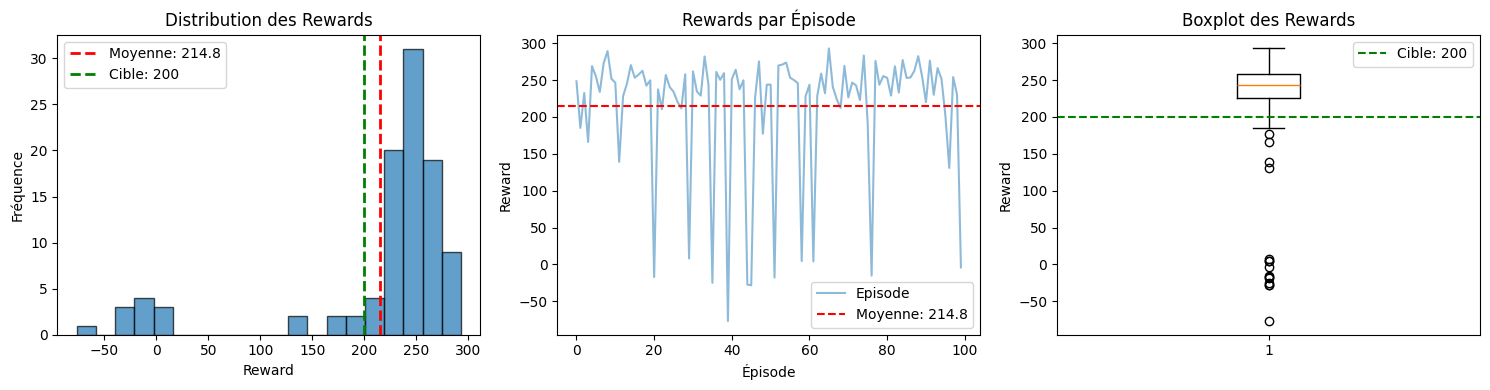

In [49]:
# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Distribution des rewards
axes[0].hist(rewards, bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(rewards), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {np.mean(rewards):.1f}')
axes[0].axvline(200, color='green', linestyle='--', linewidth=2, label='Cible: 200')
axes[0].set_xlabel('Reward')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des Rewards')
axes[0].legend()

# 2. Évolution des rewards
axes[1].plot(rewards, alpha=0.5, label='Episode')
axes[1].axhline(np.mean(rewards), color='red', linestyle='--', label=f'Moyenne: {np.mean(rewards):.1f}')
axes[1].set_xlabel('Épisode')
axes[1].set_ylabel('Reward')
axes[1].set_title('Rewards par Épisode')
axes[1].legend()

# 3. Boxplot
axes[2].boxplot(rewards, vert=True)
axes[2].axhline(200, color='green', linestyle='--', label='Cible: 200')
axes[2].set_ylabel('Reward')
axes[2].set_title('Boxplot des Rewards')
axes[2].legend()

plt.tight_layout()
plt.show()

---

## 🏆 Conclusion

### Ce qu'on a accompli

| Compétence | Status |
|-----------|--------|
| Explorer l'environnement LunarLander | ✅ |
| Entraîner un agent PPO | ✅ |
| Atteindre > 200 points | ✅ |
| Évaluer et visualiser les performances | ✅ |
| Sauvegarder et charger le modèle | ✅ |

### Livrables

1. **Notebook complet**
2. **Vidéo** - Enregistrer un atterrissage réussi à faire
3. **API FastAPI** - Créer un endpoint `/play` pour jouer
4. **GUI Streamlit** - Interface pour voir l'agent jouer
5. **Dashboard** - Tableau de bord des métriques

### Concepts clés appris

```
PPO = Policy Gradient + Clipping + GAE
```

- **PPO** : algorithme de policy gradient avec limitation du changement de politique
- **MlpPolicy** : réseau de neurones pour approcher la politique
- **deterministic=True** : exploitation maximale pour l'évaluation